# Model dự báo MG95

Notebook này dùng các file đã chia `train/val/test` cho 3 horizon:

- `MG95_t_plus_1`
- `MG95_t_plus_3`
- `MG95_t_plus_7`

Nguyên tắc:
- Train dùng để học.
- Validation dùng để chọn model.
- Test chỉ dùng để đánh giá cuối cùng.
- Không shuffle dữ liệu vì đây là chuỗi thời gian.


In [16]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
HORIZONS = [1, 3, 7]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Tìm thư mục chứa dữ liệu train/val/test

Notebook sẽ tự tìm thư mục `Data_Train_Val_Test` trong `DACS_2`.

Nếu không tìm thấy, bạn chỉ cần sửa biến `SPLIT_ROOT` thành đường dẫn thư mục chứa 3 folder:

```text
MG95_t_plus_1/
MG95_t_plus_3/
MG95_t_plus_7/
```


In [17]:
# Cách 1: tự tìm trong Google Drive
SEARCH_ROOT = "/content/drive/MyDrive/DACS_2"

candidates = glob.glob(
    os.path.join(SEARCH_ROOT, "**", "Data_Train_Val_Test"),
    recursive=True
)

if len(candidates) > 0:
    SPLIT_ROOT = candidates[0]
else:
    # Nếu chạy ngoài Colab hoặc không tự tìm thấy, sửa dòng này thủ công
    SPLIT_ROOT = "Data_Train_Val_Test"

print("SPLIT_ROOT:", SPLIT_ROOT)
print("Tồn tại chưa:", os.path.exists(SPLIT_ROOT))

if os.path.exists(SPLIT_ROOT):
    print("Các thư mục/file bên trong:")
    for item in os.listdir(SPLIT_ROOT):
        print("-", item)


SPLIT_ROOT: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test
Tồn tại chưa: True
Các thư mục/file bên trong:
- MG95_t_plus_1
- MG95_t_plus_3
- MG95_t_plus_7
- model_results_all_horizons.csv


## 2. Hàm đọc dữ liệu cho từng horizon

In [18]:
def find_horizon_folder(split_root, horizon):
    """Tìm folder MG95_t_plus_h trong SPLIT_ROOT."""
    direct = os.path.join(split_root, f"MG95_t_plus_{horizon}")
    if os.path.exists(direct):
        return direct

    matches = glob.glob(
        os.path.join(split_root, f"*t_plus_{horizon}*")
    )
    matches = [m for m in matches if os.path.isdir(m)]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Không tìm thấy folder cho t+{horizon} trong: {split_root}"
        )

    return matches[0]


def load_split_data(split_root, horizon):
    """Đọc train.csv, val.csv, test.csv cho horizon h."""
    folder = find_horizon_folder(split_root, horizon)

    train_path = os.path.join(folder, "train.csv")
    val_path = os.path.join(folder, "val.csv")
    test_path = os.path.join(folder, "test.csv")

    for p in [train_path, val_path, test_path]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Thiếu file: {p}")

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    for df in [train_df, val_df, test_df]:
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    target_col = f"MG95_t_+_{horizon}" # Corrected to match the actual column name in train.csv

    print(f"[DEBUG] Columns in train.csv for horizon t+{horizon}: {train_df.columns.tolist()}") # Added for debugging

    if target_col not in train_df.columns:
        raise ValueError(f"Không thấy target {target_col} trong train.csv")

    feature_cols = [
        col for col in train_df.columns
        if col not in ["Date", target_col]
    ]

    # Chỉ lấy feature dạng số để tránh lỗi model
    numeric_feature_cols = train_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

    return {
        "horizon": horizon,
        "folder": folder,
        "target_col": target_col,
        "feature_cols": numeric_feature_cols,
        "train": train_df,
        "val": val_df,
        "test": test_df
    }


# Kiểm tra nhanh 3 bộ dữ liệu
for h in HORIZONS:
    data = load_split_data(SPLIT_ROOT, h)
    print(f"\n===== t+{h} ====")
    print("Folder:", data["folder"])
    print("Target:", data["target_col"])
    print("Số feature:", len(data["feature_cols"]))
    print("Train:", data["train"].shape)
    print("Val  :", data["val"].shape)
    print("Test :", data["test"].shape)
    if "Date" in data["train"].columns:
        print("Train date:", data["train"]["Date"].min(), "→", data["train"]["Date"].max())
        print("Val date  :", data["val"]["Date"].min(), "→", data["val"]["Date"].max())
        print("Test date :", data["test"]["Date"].min(), "→", data["test"]["Date"].max())

[DEBUG] Columns in train.csv for horizon t+1: ['MG95_lag1', 'MG95_lag3', 'MG95_lag7', 'MG95_return1', 'MG95_return5', 'MG95_MA5_lag1', 'MG95_STD20_lag1', 'BRT_KH_return1', 'WTI_return1', 'GPRD_lag1', 'GPRD_lag3', 'GPRD_lag7', 'GPRD_MA7_lag1', 'Has_GPR_Event', 'NgayLe', 'GanNgayLe', 'SuKienDacBiet', 'IsMonthStart', 'IsMonthEnd', 'Month', 'Quarter', 'DayOfWeek', 'MG95_t_+_1']

===== t+1 ====
Folder: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_1
Target: MG95_t_+_1
Số feature: 22
Train: (2798, 23)
Val  : (600, 23)
Test : (600, 23)
[DEBUG] Columns in train.csv for horizon t+3: ['MG95_lag1', 'MG95_lag3', 'MG95_lag7', 'MG95_return1', 'MG95_return5', 'MG95_MA5_lag1', 'MG95_STD20_lag1', 'BRT_KH_return1', 'WTI_return1', 'GPRD_lag1', 'GPRD_lag3', 'GPRD_lag7', 'GPRD_MA7_lag1', 'Has_GPR_Event', 'NgayLe', 'GanNgayLe', 'SuKienDacBiet', 'IsMonthStart', 'IsMonthEnd', 'Month', 'Quarter', 'DayOfWeek', 'MG95_t_+_3']

===== t+3 ====
Folder: /content/drive/MyDrive/DACS_2/data/Data_Tra

## 3. Metrics đánh giá model

In [19]:
def evaluate_regression(y_true, y_pred):
    """Tính các chỉ số đánh giá hồi quy."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE tránh chia cho 0
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape,
        "R2": r2
    }


## 4. Khai báo model

Các model dùng trước:

1. **Naive baseline**: lấy giá gần nhất làm dự báo.
2. **Ridge Regression**: baseline tuyến tính có regularization.
3. **Random Forest**: model phi tuyến, có giới hạn độ sâu để giảm overfitting.
4. **HistGradientBoosting**: boosting model trong sklearn.
5. **SVR**: model phi tuyến, cần scale.

Sau khi có kết quả này, nếu cần mới chạy LSTM riêng.


In [20]:
def get_models():
    models = {
        "Ridge": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.05,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            ))
        ]),

        "SVR": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVR(
                kernel="rbf",
                C=10,
                epsilon=0.1
            ))
        ])
    }

    return models


## 5. Train model cho 1 horizon

In [21]:
def train_one_horizon(split_root, horizon):
    data = load_split_data(split_root, horizon)

    target_col = data["target_col"]
    feature_cols = data["feature_cols"]

    train_df = data["train"].dropna(subset=[target_col]).copy()
    val_df = data["val"].dropna(subset=[target_col]).copy()
    test_df = data["test"].dropna(subset=[target_col]).copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_val = val_df[feature_cols]
    y_val = val_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    results = []
    predictions = {}

    # Naive baseline: ưu tiên MG95_lag1
    baseline_col = None
    if "MG95_lag1" in feature_cols:
        baseline_col = "MG95_lag1"
    else:
        mg95_lag_cols = [c for c in feature_cols if "MG95" in c and "lag" in c.lower()]
        if len(mg95_lag_cols) > 0:
            baseline_col = mg95_lag_cols[0]

    if baseline_col is not None:
        for split_name, X_split, y_split in [
            ("train", X_train, y_train),
            ("val", X_val, y_val),
            ("test", X_test, y_test)
        ]:
            y_pred = X_split[baseline_col].values
            metrics = evaluate_regression(y_split, y_pred)
            results.append({
                "Horizon": horizon,
                "Model": f"Naive_{baseline_col}",
                "Split": split_name,
                **metrics
            })

        predictions[f"Naive_{baseline_col}"] = X_test[baseline_col].values

    # ML models
    models = get_models()

    trained_models = {}

    for model_name, model in models.items():
        print(f"Training t+{horizon} - {model_name} ...")

        model.fit(X_train, y_train)
        trained_models[model_name] = model

        for split_name, X_split, y_split in [
            ("train", X_train, y_train),
            ("val", X_val, y_val),
            ("test", X_test, y_test)
        ]:
            y_pred = model.predict(X_split)
            metrics = evaluate_regression(y_split, y_pred)

            results.append({
                "Horizon": horizon,
                "Model": model_name,
                "Split": split_name,
                **metrics
            })

        predictions[model_name] = model.predict(X_test)

    results_df = pd.DataFrame(results)

    # Chọn model tốt nhất theo Validation RMSE
    val_results = results_df[results_df["Split"] == "val"].copy()
    best_row = val_results.sort_values("RMSE").iloc[0]
    best_model_name = best_row["Model"]

    print(f"\nBest model t+{horizon} theo Validation RMSE:", best_model_name)
    print(best_row)

    # Lưu model tốt nhất nếu không phải naive
    output_folder = data["folder"]
    model_folder = os.path.join(output_folder, "models")
    os.makedirs(model_folder, exist_ok=True)

    if best_model_name in trained_models:
        model_path = os.path.join(model_folder, f"best_model_t_plus_{horizon}_{best_model_name}.pkl")
        joblib.dump({
            "model": trained_models[best_model_name],
            "feature_cols": feature_cols,
            "target_col": target_col,
            "horizon": horizon
        }, model_path)
        print("Đã lưu model:", model_path)
    else:
        print("Best model là Naive baseline nên không lưu file .pkl")

    # Lưu kết quả
    results_path = os.path.join(output_folder, f"model_results_t_plus_{horizon}.csv")
    results_df.to_csv(results_path, index=False, encoding="utf-8-sig")
    print("Đã lưu kết quả:", results_path)

    # Lưu dự báo test của model tốt nhất
    pred_df = pd.DataFrame()
    if "Date" in test_df.columns:
        pred_df["Date"] = test_df["Date"]

    pred_df["Actual"] = y_test.values
    pred_df["Predicted"] = predictions[best_model_name]
    pred_df["Error"] = pred_df["Actual"] - pred_df["Predicted"]
    pred_df["Best_Model"] = best_model_name
    pred_df["Horizon"] = horizon

    pred_path = os.path.join(output_folder, f"test_predictions_t_plus_{horizon}.csv")
    pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
    print("Đã lưu dự báo test:", pred_path)

    return results_df, pred_df, best_model_name


## 6. Chạy model cho t+1, t+3, t+7

In [22]:
all_results = []
all_predictions = {}
best_models = {}

for h in HORIZONS:
    print("\n" + "=" * 80)
    print(f"CHẠY MODEL CHO MG95 t+{h}")
    print("=" * 80)

    results_df, pred_df, best_model_name = train_one_horizon(SPLIT_ROOT, h)

    all_results.append(results_df)
    all_predictions[h] = pred_df
    best_models[h] = best_model_name

final_results = pd.concat(all_results, ignore_index=True)

display(final_results.sort_values(["Horizon", "Split", "RMSE"]))
print("Best models:", best_models)



CHẠY MODEL CHO MG95 t+1
[DEBUG] Columns in train.csv for horizon t+1: ['MG95_lag1', 'MG95_lag3', 'MG95_lag7', 'MG95_return1', 'MG95_return5', 'MG95_MA5_lag1', 'MG95_STD20_lag1', 'BRT_KH_return1', 'WTI_return1', 'GPRD_lag1', 'GPRD_lag3', 'GPRD_lag7', 'GPRD_MA7_lag1', 'Has_GPR_Event', 'NgayLe', 'GanNgayLe', 'SuKienDacBiet', 'IsMonthStart', 'IsMonthEnd', 'Month', 'Quarter', 'DayOfWeek', 'MG95_t_+_1']
Training t+1 - Ridge ...
Training t+1 - RandomForest ...
Training t+1 - HistGradientBoosting ...
Training t+1 - SVR ...

Best model t+1 theo Validation RMSE: Ridge
Horizon           1
Model         Ridge
Split           val
RMSE        2.84037
MAE        1.865654
MAPE_%     1.952232
R2         0.989513
Name: 4, dtype: object
Đã lưu model: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_1/models/best_model_t_plus_1_Ridge.pkl
Đã lưu kết quả: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_1/model_results_t_plus_1.csv
Đã lưu dự báo test: /content/drive/MyDr

,Horizon,Model,Split,RMSE,MAE,MAPE_%,R2
11,1,HistGradientBoosting,test,1.532925,1.193910,1.305343,0.975405
5,1,Ridge,test,1.673992,1.281381,1.394857,0.970670
8,1,RandomForest,test,1.717476,1.274369,1.395247,0.969127
2,1,Naive_MG95_lag1,test,2.345431,1.804333,1.988513,0.942423
14,1,SVR,test,8.346324,5.657776,5.958564,0.270894
9,1,HistGradientBoosting,train,0.650193,0.498979,0.646943,0.999429
6,1,RandomForest,train,1.225604,0.884740,1.180211,0.997971
3,1,Ridge,train,1.732329,1.246624,1.731435,0.995946
0,1,Naive_MG95_lag1,train,2.421741,1.816569,2.388627,0.992076
12,1,SVR,train,3.469855,1.381116,2.606839,0.983734


Best models: {1: 'Ridge', 3: 'Ridge', 7: 'Naive_MG95_lag1'}


## 7. Bảng so sánh Validation và Test

In [23]:
summary = final_results[
    final_results["Split"].isin(["val", "test"])
].copy()

summary_pivot = summary.pivot_table(
    index=["Horizon", "Model"],
    columns="Split",
    values=["RMSE", "MAE", "MAPE_%", "R2"]
)

display(summary_pivot)

# Lưu bảng tổng hợp
summary_path = os.path.join(SPLIT_ROOT, "model_results_all_horizons.csv")
final_results.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("Đã lưu bảng tổng hợp:", summary_path)


MAE               MAPE_%                   R2                RMSE           
Split                             test        val      test        val      test       val      test        val
Horizon Model                                                                                                  
1       HistGradientBoosting  1.193910   2.112051  1.305343   2.095122  0.975405  0.982785  1.532925   3.639216
        Naive_MG95_lag1       1.804333   2.616700  1.988513   2.772952  0.942423  0.980927  2.345431   3.830565
        RandomForest          1.274369   2.343642  1.395247   2.299546  0.969127  0.980040  1.717476   3.918618
        Ridge                 1.281381   1.865654  1.394857   1.952232  0.970670  0.989513  1.673992   2.840370
        SVR                   5.657776  10.815800  5.958564   9.296825  0.270894  0.453779  8.346324  20.499294
3       HistGradientBoosting  2.936923   3.906717  3.207376   3.954693  0.857993  0.956723  3.671416   5.792931
        Naive_MG95_lag1       2.547967   3.548314  2.813393   3.774186  0.883332  0.965166  3.327780   5.197190
        RandomForest          2.434008   3.733642  2.671935   3.776362  0.896001  0.961126  3.141902   5.490337
        Ridge                 2.437611   3.232175  2.661535   3.371983  0.899831  0.970347  3.083511   4.795136
        SVR                   6.064238  11.766334  6.419245  10.419379  0.248113  0.425774  8.448015  21.101302
7       HistGradientBoosting  5.374282   5.926950  5.866963   6.235848  0.528089  0.909683  6.635143   8.343313
        Naive_MG95_lag1       3.396110   4.884207  3.744935   5.237248  0.793313  0.937468  4.391135   6.942329
        RandomForest          3.929250   5.684904  4.309267   5.844970  0.721585  0.917151  5.096434   7.990906
        Ridge                 3.780340   4.955696  4.121345   5.172414  0.756750  0.934824  4.763722   7.087594
        SVR                   7.575998  13.249990  8.029972  12.040895 -0.034736  0.349361  9.825057  22.393592

Đã lưu bảng tổng hợp: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/model_results_all_horizons.csv


## 8. Vẽ Actual vs Predicted trên tập Test

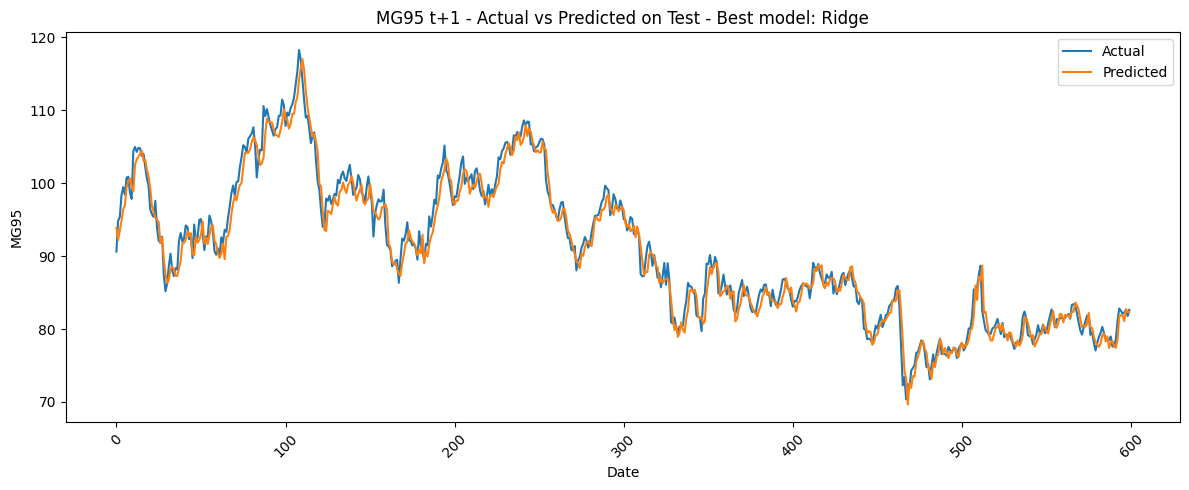

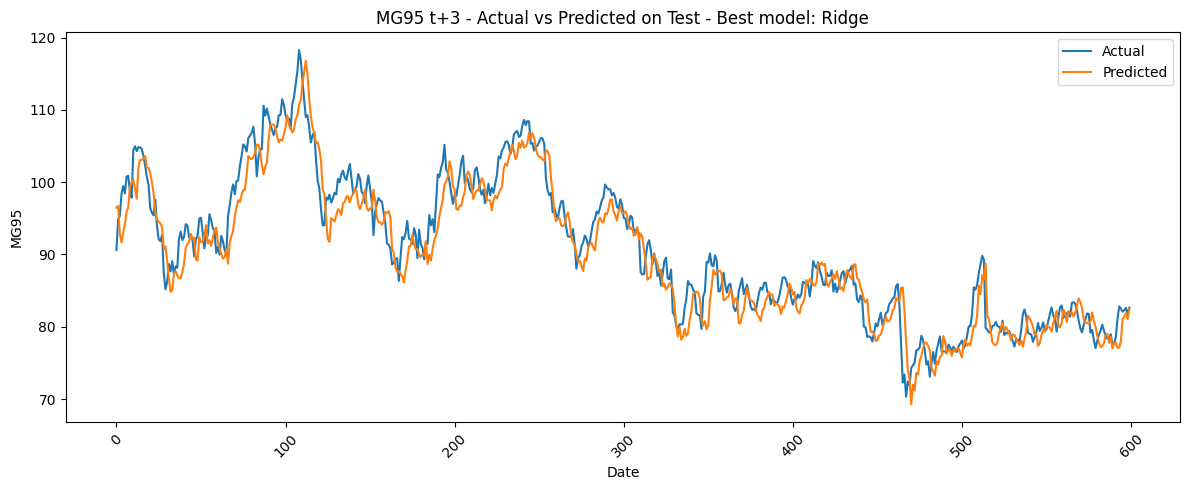

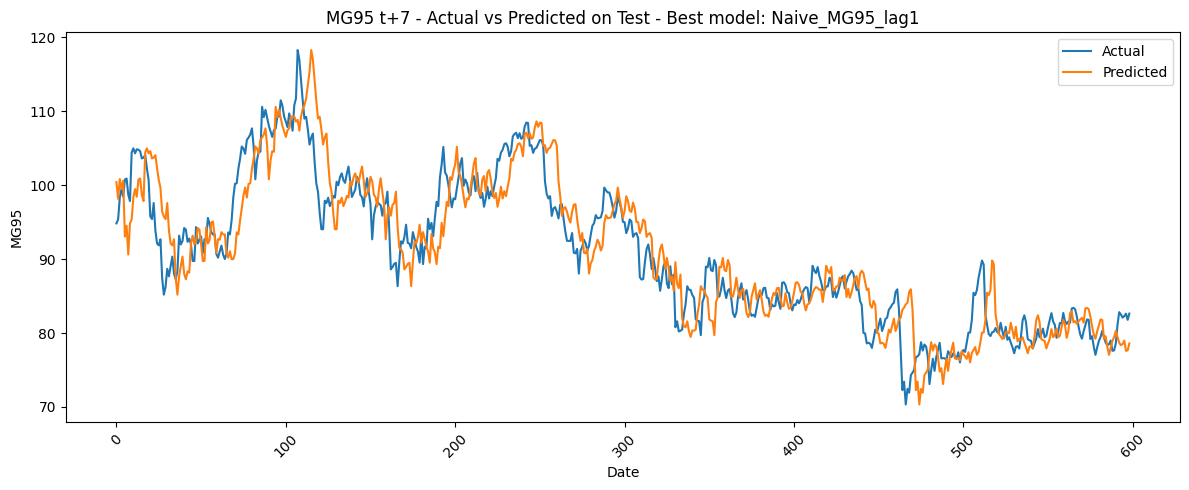

In [24]:
for h, pred_df in all_predictions.items():
    plt.figure(figsize=(12, 5))

    if "Date" in pred_df.columns:
        x_axis = pred_df["Date"]
    else:
        x_axis = range(len(pred_df))

    plt.plot(x_axis, pred_df["Actual"], label="Actual")
    plt.plot(x_axis, pred_df["Predicted"], label="Predicted")

    plt.title(f"MG95 t+{h} - Actual vs Predicted on Test - Best model: {best_models[h]}")
    plt.xlabel("Date")
    plt.ylabel("MG95")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 9. Nhận xét overfitting

Nhìn bảng kết quả:

- Nếu RMSE train thấp hơn rất nhiều so với val/test → model bị overfitting.
- Nếu train, val, test đều cao → model đang underfitting hoặc feature chưa đủ tốt.
- Chọn model dựa trên validation, sau đó báo cáo kết quả cuối cùng trên test.

Không dùng test để chỉnh model.


In [25]:
# Bảng kiểm tra gap train - val - test theo RMSE
rmse_table = final_results.pivot_table(
    index=["Horizon", "Model"],
    columns="Split",
    values="RMSE"
).reset_index()

if {"train", "val", "test"}.issubset(rmse_table.columns):
    rmse_table["val_train_gap"] = rmse_table["val"] - rmse_table["train"]
    rmse_table["test_train_gap"] = rmse_table["test"] - rmse_table["train"]

display(rmse_table.sort_values(["Horizon", "val"]))


Split,Horizon,Model,test,train,val,val_train_gap,test_train_gap
3,1,Ridge,1.673992,1.732329,2.840370,1.108041,-0.058337
0,1,HistGradientBoosting,1.532925,0.650193,3.639216,2.989023,0.882732
1,1,Naive_MG95_lag1,2.345431,2.421741,3.830565,1.408824,-0.076310
2,1,RandomForest,1.717476,1.225604,3.918618,2.693015,0.491872
4,1,SVR,8.346324,3.469855,20.499294,17.029438,4.876468
8,3,Ridge,3.083511,2.910987,4.795136,1.884149,0.172524
6,3,Naive_MG95_lag1,3.327780,3.426262,5.197190,1.770928,-0.098482
7,3,RandomForest,3.141902,2.080705,5.490337,3.409631,1.061197
5,3,HistGradientBoosting,3.671416,1.197968,5.792931,4.594964,2.473449
9,3,SVR,8.448015,3.992292,21.101302,17.109010,4.455723


## 10. Visualizing Model Performance

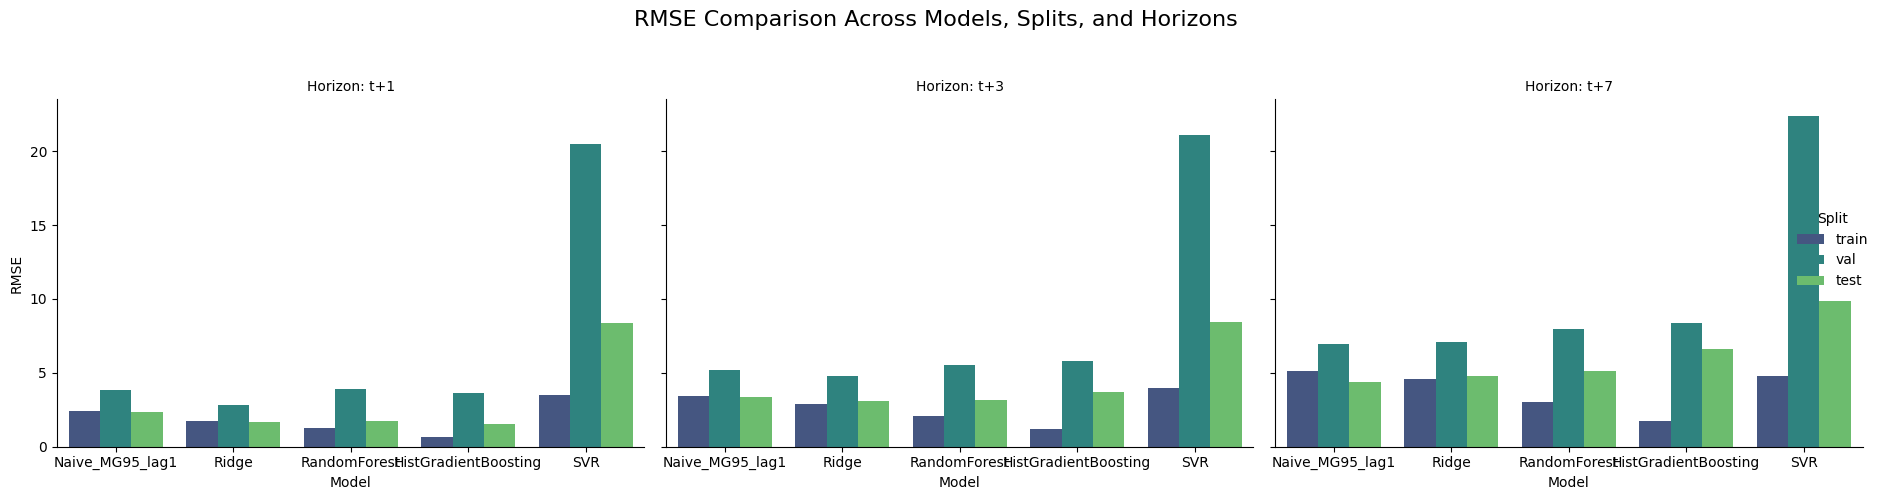

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize RMSE across models and horizons
# Use sns.catplot for faceting by 'Horizon'
g = sns.catplot(
    data=final_results, x='Model', y='RMSE', hue='Split', col='Horizon', col_wrap=3,
    kind='bar', height=5, aspect=1.2, palette='viridis', legend_out=True
)
g.set_axis_labels("Model", "RMSE")
g.set_titles("Horizon: t+{col_name}")
g.fig.suptitle('RMSE Comparison Across Models, Splits, and Horizons', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Next, let's visualize the distribution of errors (Actual - Predicted) for the best model of each horizon on the test set. This can help us understand the nature of the model's predictions.

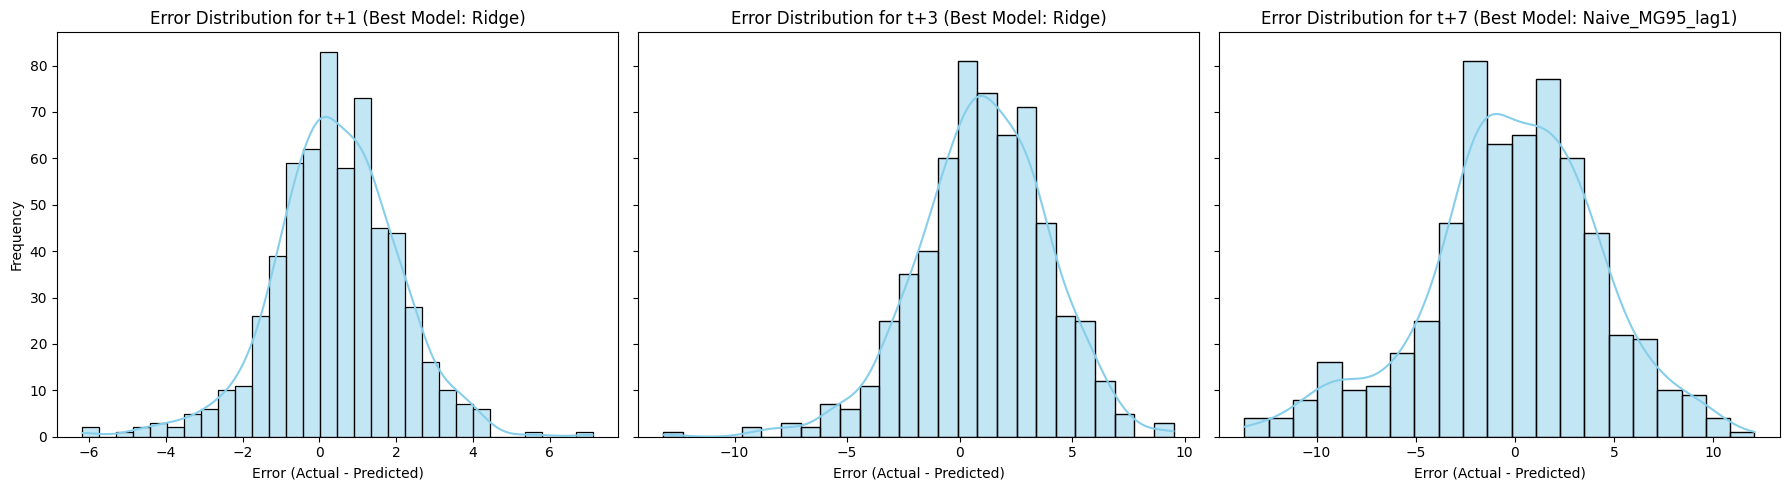

In [27]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(18, 5), sharey=True)

for i, h in enumerate(HORIZONS):
    pred_df = all_predictions[h]
    best_model = best_models[h]

    sns.histplot(pred_df['Error'], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Error Distribution for t+{h} (Best Model: {best_model})')
    axes[i].set_xlabel('Error (Actual - Predicted)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## Gợi ý báo cáo

Bạn có thể viết:

> Sau khi chia dữ liệu theo thứ tự thời gian thành train/validation/test, nhóm xây dựng các mô hình dự báo MG95 cho ba khoảng dự báo t+1, t+3 và t+7. Tập validation được dùng để lựa chọn mô hình tốt nhất dựa trên RMSE, trong khi tập test chỉ được sử dụng để đánh giá cuối cùng. Các mô hình được so sánh gồm Naive baseline, Ridge Regression, Random Forest, HistGradientBoosting và SVR. Việc so sánh với Naive baseline giúp kiểm tra mô hình học máy có thực sự cải thiện so với phương pháp dự báo đơn giản hay không.
